In [5]:
## importing the required libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
## Loading the dataset--

df = pd.read_csv("train.csv")
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [7]:
df.shape

(439140, 16)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [9]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

* It returns that their is no null values in the dataset.

**Data Preprocessing** ----

In [10]:
matrix = df.corr(method='pearson', min_periods=1, numeric_only=True)

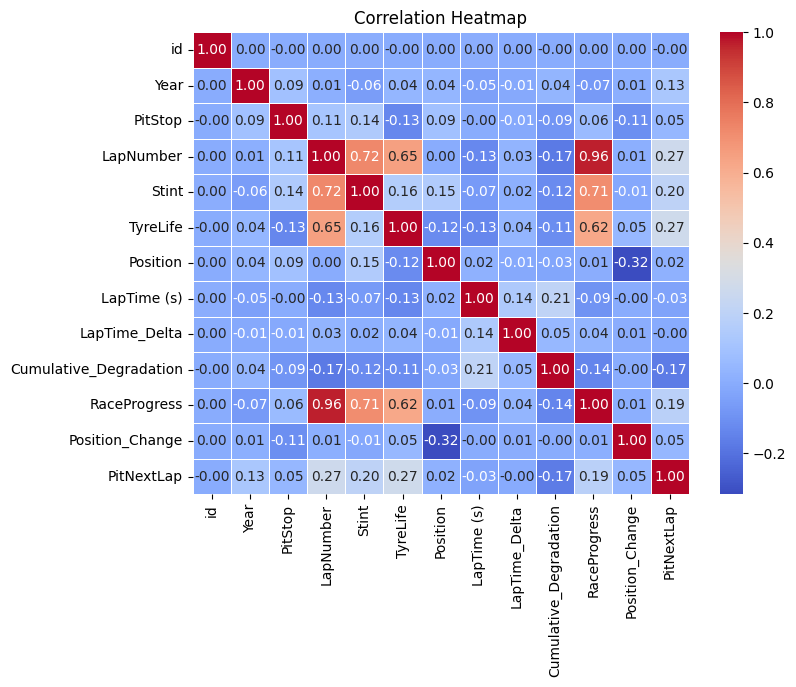

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
cat_col = []

for col in df.columns:
    if df[col].dtype == 'object':
        cat_col.append(col)

In [13]:
def data_interpretation(df,column):
    for col in column:
        print(f"\nColumn: {col}")
        print(df[col].value_counts())
data_interpretation(df,cat_col)


Column: Driver
Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D723       1
D677       1
D731       1
D716       1
D714       1
Name: count, Length: 887, dtype: int64

Column: Compound
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

Column: Race
Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand

In [14]:
df = df.drop(['LapTime_Delta','LapNumber'],axis=1)

In [15]:
df.head(3)

,id,Driver,Compound,Race,Year,PitStop,Stint,TyreLife,Position,LapTime (s),Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,2,39.0,8,78.491,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,2,7.0,4,75.095,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,3,22.0,13,70.945,-100.529,0.819444,3.0,1.0


In [16]:
## Importing Libraries for Features Selection
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [17]:
def Label_encoding(df,column):
    for col in column:
        le = LabelEncoder()  # create new encoder per column
        print(f"Encoding column: {col}")
        df[col] = le.fit_transform(df[col].astype(str))

Label_encoding(df,['Driver','Race'])

Encoding column: Driver
Encoding column: Race


In [18]:
from sklearn.preprocessing import OneHotEncoder

def One_Hot_Encoding(df, cols):
    # Initialize with sparse_output=False to get a numpy array
    hot_enco = OneHotEncoder(sparse_output=False) 
    
    for col in cols:
        print(f"Encoding column: {col}")
        
        # USE DOUBLE BRACKETS [[col]] to keep it 2D
        encoded_data = hot_enco.fit_transform(df[[col]].astype(str))
        
        # Create a DataFrame from the encoded data with proper column names
        encoded_df = pd.DataFrame(
            encoded_data, 
            columns=hot_enco.get_feature_names_out([col]),
            index=df.index
        )
        
        # Join the new columns and drop the original
        df = pd.concat([df, encoded_df], axis=1).drop(columns=[col])
        
    return df

# Usage
df = One_Hot_Encoding(df, ['Compound'])

Encoding column: Compound


In [19]:
df.head(3)

,id,Driver,Race,Year,PitStop,Stint,TyreLife,Position,LapTime (s),Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET
0,0,134,7,2022,0,2,39.0,8,78.491,21.019,0.714286,5.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1,111,9,2025,1,2,7.0,4,75.095,-223.207,0.346154,-3.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2,886,2,2022,0,3,22.0,13,70.945,-100.529,0.819444,3.0,1.0,1.0,0.0,0.0,0.0,0.0


In [20]:
df.shape

(439140, 18)

**Train Data Of Making Model**

In [21]:
train_id = df['id']

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
X = df.drop(['id','PitNextLap'],axis=1)
y = df['PitNextLap']

scale = StandardScaler()
X = scale.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [24]:
X_train.shape , X_test.shape

((351312, 16), (87828, 16))

In [25]:
print(pd.DataFrame(X_train))

              0         1         2         3         4         5         6   \
0       1.268146 -1.562950 -0.510810 -0.396946 -0.830476 -0.934387 -0.119410   
1       1.400600  0.559574 -1.486487 -0.396946 -0.830476 -1.036414  1.964411   
2       1.415317  0.692232  1.440545 -0.396946 -0.830476 -1.240468  0.638343   
3       1.485959 -0.767003 -0.510810 -0.396946  0.221941  1.922369  1.017219   
4       1.332901 -0.501688  1.440545 -0.396946 -0.830476 -0.934387  1.774973   
...          ...       ...       ...       ...       ...       ...       ...   
351307  0.179081  0.824890 -0.510810 -0.396946 -0.830476 -1.342495  1.585534   
351308  1.262259  0.161601  1.440545 -0.396946 -0.830476 -0.628306  0.259466   
351309 -0.595037 -0.767003 -0.510810 -0.396946 -0.830476  1.208180 -1.256040   
351310 -0.742208 -1.562950 -0.510810 -0.396946 -0.830476 -0.832360  0.827781   
351311 -0.942361  1.488178  0.464868 -0.396946 -0.830476  0.698045  0.259466   

              7         8         9    

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor


In [27]:
def evaluate_model(true, predicted):
    roc = roc_auc_score(true, predicted)
    return roc

In [29]:
models = {
    "RandomForest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=False)
}

model_lists = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    # Evaluate the model
    train_roc = evaluate_model(y_train, y_train_pred)
    test_roc= evaluate_model(y_test, y_test_pred)
    print(list(models.keys())[i])
    model_lists.append(list(models.keys())[i])
    print('model performance on training set:')
    print(f'ROC: {train_roc}')
    print('model performance on testing set:')
    print(f'ROC: {test_roc}')
    print('-----------------------------------')


RandomForest
model performance on training set:
ROC: 0.9999999993641199
model performance on testing set:
ROC: 0.9382635276338409
-----------------------------------
AdaBoost
model performance on training set:
ROC: 0.8931812071506056
model performance on testing set:
ROC: 0.8943077680473096
-----------------------------------
XGBRegressor
model performance on training set:
ROC: 0.9476346872707483
model performance on testing set:
ROC: 0.9403726534790169
-----------------------------------
CatBoost
model performance on training set:
ROC: 0.9463866237067994
model performance on testing set:
ROC: 0.9419101620714089
-----------------------------------
